#LSTM Model for time-series forecasting

##Visualizing the Original Dataset

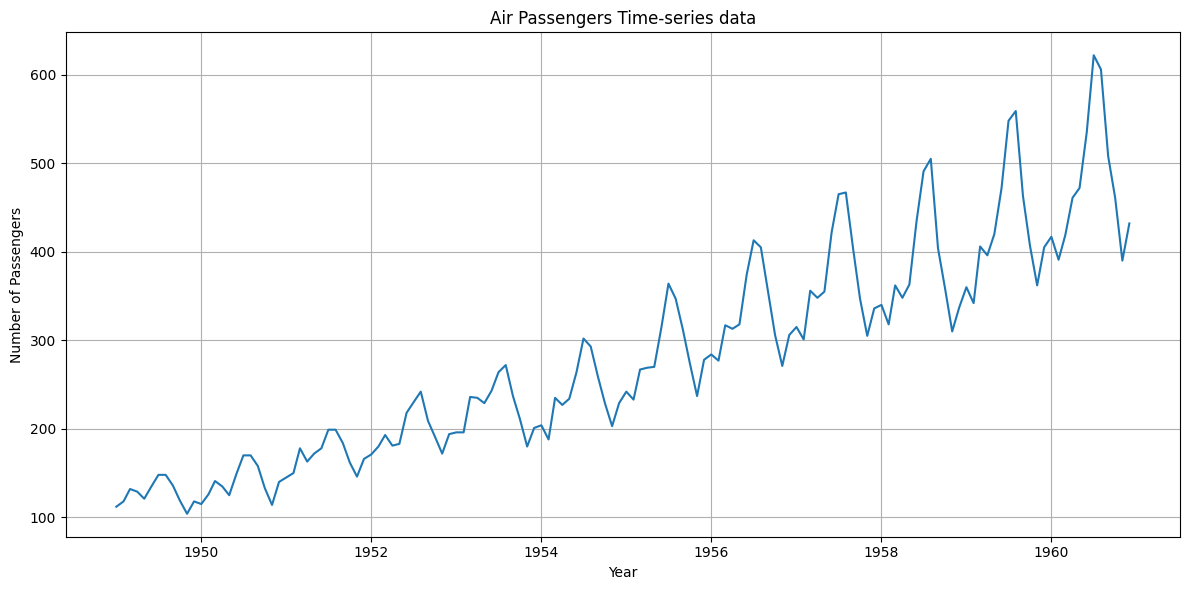

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('AirPassengers.csv')
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['#Passengers'], linestyle='-')
plt.title('Air Passengers Time-series data')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.grid(True)
plt.tight_layout()
plt.show()


##Preprocessing the data

In [ ]:
import numpy as np
from datetime import datetime


data = pd.read_csv('AirPassengers.csv')
data['Month'] = pd.to_datetime(data['Month'])
data.set_index('Month', inplace=True)
passengers = data['#Passengers'].values.astype(float)
passengers = (passengers - np.min(passengers)) / (np.max(passengers) - np.min(passengers))


##Dataset for the LSTM Model

In [ ]:

sequence_length = 12
X = []
y = []
for i in range(len(passengers) - sequence_length):
    X.append(passengers[i:i+sequence_length])
    y.append(passengers[i+sequence_length])
X = np.array(X)
y = np.array(y)

X = np.reshape(X, (X.shape[0], X.shape[1], 1))

##Activation Functions and their gradients

In [ ]:


def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def dsigmoid(x):
    return x * (1 - x)

def tanh(x):
    return np.tanh(x)

def dtanh(x):
    return 1 - x ** 2


##Declaring the LSTM Class

In [ ]:
class LSTM:
    def __init__(self, input_size, hidden_size, output_size):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.Wf = np.random.randn(hidden_size, hidden_size + input_size) * 0.1
        self.bf = np.zeros((hidden_size, 1))
        self.Wi = np.random.randn(hidden_size, hidden_size + input_size) * 0.1
        self.bi = np.zeros((hidden_size, 1))
        self.Wc = np.random.randn(hidden_size, hidden_size + input_size) * 0.1
        self.bc = np.zeros((hidden_size, 1))
        self.Wo = np.random.randn(hidden_size, hidden_size + input_size) * 0.1
        self.bo = np.zeros((hidden_size, 1))
        self.Wy = np.random.randn(output_size, hidden_size) * 0.1
        self.by = np.zeros((output_size, 1))

    def forward(self, inputs):
        h_prev = np.zeros((self.hidden_size, 1))
        c_prev = np.zeros((self.hidden_size, 1))
        self.x_s, self.f_s, self.i_s, self.c_s, self.o_s, self.h_s = {}, {}, {}, {}, {}, {}
        self.c_s[-1] = c_prev
        self.h_s[-1] = h_prev
        for t in range(len(inputs)):
            x = inputs[t].reshape(-1, 1)
            concat = np.vstack((self.h_s[t-1], x))
            f = sigmoid(np.dot(self.Wf, concat) + self.bf)
            i = sigmoid(np.dot(self.Wi, concat) + self.bi)
            c_bar = tanh(np.dot(self.Wc, concat) + self.bc)
            c = f * self.c_s[t-1] + i * c_bar
            o = sigmoid(np.dot(self.Wo, concat) + self.bo)
            h = o * tanh(c)
            self.x_s[t] = x
            self.f_s[t] = f
            self.i_s[t] = i
            self.c_s[t] = c
            self.o_s[t] = o
            self.h_s[t] = h
        y = np.dot(self.Wy, h) + self.by
        return y, h, c

    def backward(self, dy, learning_rate=0.01):
        dWy = np.dot(dy, self.h_s[len(self.h_s)-2].T)
        dby = dy
        dh_next = np.dot(self.Wy.T, dy)
        dc_next = np.zeros((self.hidden_size, 1))
        dWf = np.zeros_like(self.Wf)
        dWi = np.zeros_like(self.Wi)
        dWc = np.zeros_like(self.Wc)
        dWo = np.zeros_like(self.Wo)
        dbf = np.zeros_like(self.bf)
        dbi = np.zeros_like(self.bi)
        dbc = np.zeros_like(self.bc)
        dbo = np.zeros_like(self.bo)
        for t in reversed(range(len(self.x_s))):
            dh = dh_next
            do = dh * tanh(self.c_s[t])
            do_raw = do * dsigmoid(self.o_s[t])
            dc = dh * self.o_s[t] * dtanh(tanh(self.c_s[t])) + dc_next
            dc_bar = dc * self.i_s[t]
            dc_bar_raw = dc_bar * dtanh(self.c_s[t])
            di = dc * self.c_s[t-1]
            di_raw = di * dsigmoid(self.i_s[t])
            df = dc * self.c_s[t-1]
            df_raw = df * dsigmoid(self.f_s[t])
            concat = np.vstack((self.h_s[t-1], self.x_s[t]))
            dWf += np.dot(df_raw, concat.T)
            dWi += np.dot(di_raw, concat.T)
            dWc += np.dot(dc_bar_raw, concat.T)
            dWo += np.dot(do_raw, concat.T)
            dbf += df_raw
            dbi += di_raw
            dbc += dc_bar_raw
            dbo += do_raw
            dconcat = (np.dot(self.Wf.T, df_raw) + np.dot(self.Wi.T, di_raw) + np.dot(self.Wc.T, dc_bar_raw) + np.dot(self.Wo.T, do_raw))
            dh_next = dconcat[:self.hidden_size, :]
            dc_next = dc * self.f_s[t]
        self.Wf -= learning_rate * dWf
        self.Wi -= learning_rate * dWi
        self.Wc -= learning_rate * dWc
        self.Wo -= learning_rate * dWo
        self.bf -= learning_rate * dbf
        self.bi -= learning_rate * dbi
        self.bc -= learning_rate * dbc
        self.bo -= learning_rate * dbo
        self.Wy -= learning_rate * dWy
        self.by -= learning_rate * dby


##Training the LSTM Model

Epoch 1/500, Loss: 0.023822017911285277
Epoch 2/500, Loss: 0.030743928190650433
Epoch 3/500, Loss: 0.027523638349914344
Epoch 4/500, Loss: 0.024258932880730343
Epoch 5/500, Loss: 0.02142028802134809
Epoch 6/500, Loss: 0.018979528423510212
Epoch 7/500, Loss: 0.01690850087101711
Epoch 8/500, Loss: 0.01517839563962226
Epoch 9/500, Loss: 0.013757254564657704
Epoch 10/500, Loss: 0.012609724973273912
Epoch 11/500, Loss: 0.011698303399090074
Epoch 12/500, Loss: 0.010985280818815973
Epoch 13/500, Loss: 0.010434724532995848
Epoch 14/500, Loss: 0.010014050931245942
Epoch 15/500, Loss: 0.009694988131053505
Epoch 16/500, Loss: 0.00945392926947884
Epoch 17/500, Loss: 0.00927180036905017
Epoch 18/500, Loss: 0.00913361185229909
Epoch 19/500, Loss: 0.009027852636733716
Epoch 20/500, Loss: 0.008945847924594243
Epoch 21/500, Loss: 0.008881157960584342
Epoch 22/500, Loss: 0.008829057504275777
Epoch 23/500, Loss: 0.008786109032726037
Epoch 24/500, Loss: 0.008749826438678929
Epoch 25/500, Loss: 0.008718417

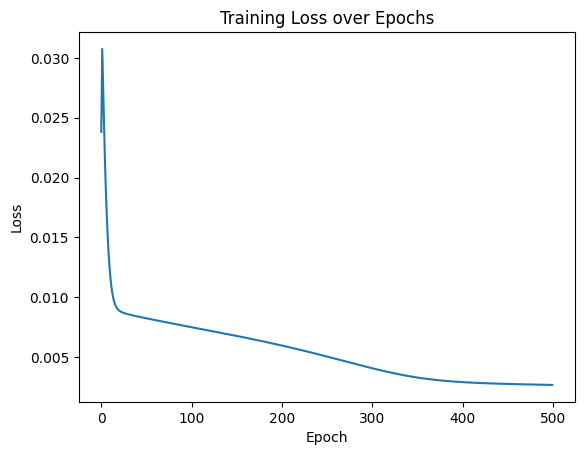

In [ ]:
input_size = 1
hidden_size = 100
output_size = 1
lstm = LSTM(input_size, hidden_size, output_size)
epochs = 500
learning_rate = 0.01
losses = []
for epoch in range(epochs):
    total_loss = 0
    for i in range(len(X)):
        inputs = X[i]
        target = y[i]
        output, h, c = lstm.forward(inputs)
        loss = (output - target) ** 2
        total_loss += loss
        dloss = 2 * (output - target)
        lstm.backward(dloss, learning_rate)
    avg_loss = total_loss / len(X)
    losses.append(avg_loss.item())
    print(f'Epoch {epoch+1}/{epochs}, Loss: {avg_loss.item()}')
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.show()


##Prediction of LSTM within the range of dates

In [ ]:

def predict_passengers(date_str):
    date = pd.to_datetime(date_str)
    if date < data.index[sequence_length] or date > data.index[-1]:
        return "Date out of range for prediction"
    idx = data.index.get_loc(date)
    input_seq = passengers[idx-sequence_length:idx]
    input_seq = input_seq.reshape(sequence_length, 1)
    output, _, _ = lstm.forward(input_seq)
    min_passengers = np.min(data['#Passengers'])
    max_passengers = np.max(data['#Passengers'])
    pred = output.item() * (max_passengers - min_passengers) + min_passengers
    return pred

example_date = '1960-08'
predicted_passengers = predict_passengers(example_date)
print(f'Predicted passengers for {example_date}: {round(predicted_passengers)}')


Predicted passengers for 1960-08: 581


##Actual VS Predicted Plot

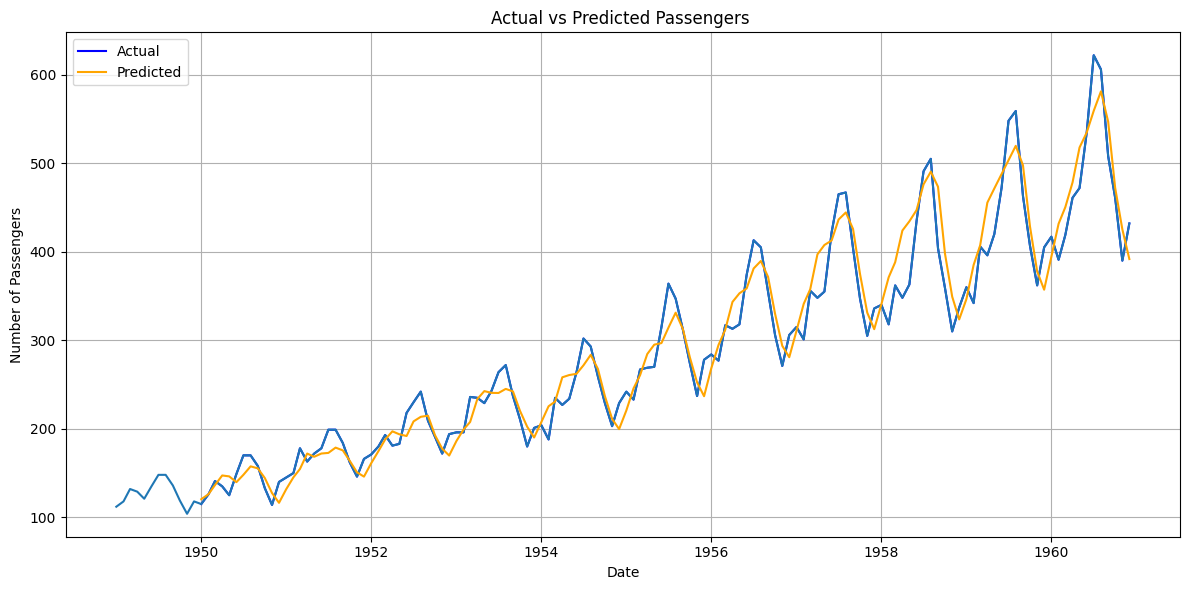

In [ ]:

predictions = []
for i in range(len(X)):
    output, _, _ = lstm.forward(X[i])
    pred = output.item() * (max_passengers - min_passengers) + min_passengers
    predictions.append(pred)

actual = df[sequence_length:]


plt.figure(figsize=(12, 6))
plt.plot(data.index[sequence_length:], actual, label='Actual', color='blue')
plt.plot(df.index, df['#Passengers'], linestyle='-')
plt.plot(data.index[sequence_length:], predictions, label='Predicted', color='orange')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.title('Actual vs Predicted Passengers ')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Accuracy of the Model

In [ ]:

def calculate_accuracy():
    predictions = []
    for i in range(len(X)):
        output, _, _ = lstm.forward(X[i])
        min_passengers = np.min(data['#Passengers'])
        max_passengers = np.max(data['#Passengers'])
        pred = output.item() * (max_passengers - min_passengers) + min_passengers
        predictions.append(pred)
    predictions = np.array(predictions)
    actual = data['#Passengers'].values[sequence_length:]
    mape = np.mean(np.abs((actual - predictions) / actual)) * 100
    accuracy = 100 - mape
    return accuracy

accuracy = calculate_accuracy()
print(f'Model prediction accuracy: {accuracy:.2f}%')

Model prediction accuracy: 92.80%


##Prediction for the year 1961

Forecast for 1961:
January 1961: 392 passengers
February 1961: 401 passengers
March 1961: 431 passengers
April 1961: 483 passengers
May 1961: 540 passengers
June 1961: 588 passengers
July 1961: 619 passengers
August 1961: 620 passengers
September 1961: 584 passengers
October 1961: 525 passengers
November 1961: 467 passengers
December 1961: 425 passengers


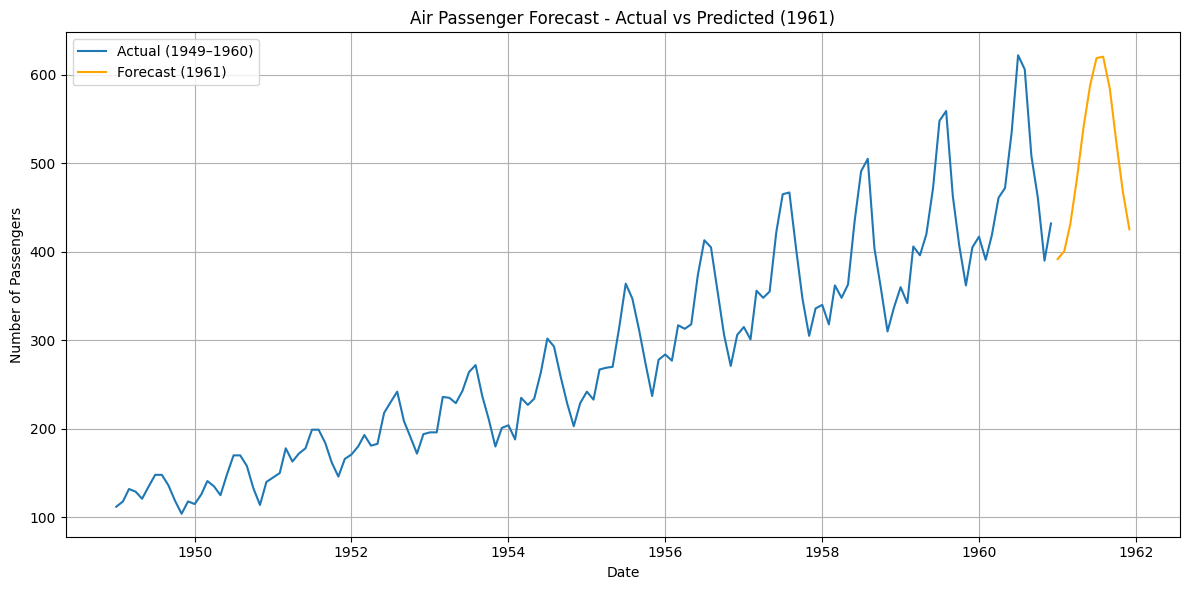

In [ ]:

def predict_future(lstm_model, last_sequence, num_predictions=12):
    predictions = []
    current_sequence = last_sequence.copy()

    for _ in range(num_predictions):
        output, _, _ = lstm_model.forward(current_sequence)
        predicted_value = output.item()
        predictions.append(predicted_value)

        current_sequence = np.roll(current_sequence, -1)
        current_sequence[-1] = predicted_value
        current_sequence = current_sequence.reshape(sequence_length, 1)

    return predictions

last_sequence = X[-1].reshape(sequence_length, 1)
future_preds = predict_future(lstm, last_sequence, num_predictions=12)
min_val = np.min(data['#Passengers'].values.astype(float))
max_val = np.max(data['#Passengers'].values.astype(float))
future_preds_denorm = [(pred * (max_val - min_val)) + min_val for pred in future_preds]


future_dates = pd.date_range(start='1961-01', periods=12, freq='MS')

print("Forecast for 1961:")

for date, value in zip(future_dates, future_preds_denorm):
    print(f"{date.strftime('%B %Y')}: {value:.0f} passengers")

all_values = data['#Passengers'].values.tolist()
all_values.extend(future_preds_denorm)

full_dates = pd.date_range(start=data.index[0], periods=len(all_values), freq='MS')
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['#Passengers'], label='Actual (1949–1960)')
plt.plot(future_dates, future_preds_denorm, label='Forecast (1961)', color='orange')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.title('Air Passenger Forecast - Actual vs Predicted (1961)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
